In [1]:
import json
import os
import pprint

import sys
import time

import psycopg2 as pg
import pandas as pd
from tqdm import trange

from eicu.data_util import sample_data
from eicu.numerical_flow import plot_dist

In [2]:
try:
    conn = pg.connect(database='eicu',user='postgres',password='123456',host='localhost',port=5432)
except Exception as e:
    print("连接数据库失败")

In [3]:
sql = 'SELECT * FROM "eicu_core"."patient"'
patient = pd.read_sql(sql,conn)
patient.head()

C:\Users\徐超\AppData\Local\Temp\ipykernel_26760\1890819563.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patient = pd.read_sql(sql,conn)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,167870,149574,Male,65,African American,73,97,"Sepsis, GI",181.4,17:18:00,...,Floor,1,admit,190.5,181.4,10:40:00,1349,Death,Expired,002-23952
1,167871,149575,Female,83,Caucasian,59,91,,144.8,19:35:00,...,ICU to SDU,4,stepdown/other,NaN,45.3,13:01:00,624,Floor,Alive,002-4770
2,167872,149575,Female,83,Caucasian,59,91,,144.8,19:35:00,...,Floor,1,admit,49.0,49.0,19:53:00,163,Step-Down Unit (SDU),Alive,002-4770
3,172607,153223,Female,70,Caucasian,63,95,,NaN,23:33:01,...,,1,stepdown/other,NaN,89.0,19:13:00,1180,Home,Alive,002-67893
4,172786,153367,Male,60,Caucasian,67,109,,182.9,20:08:00,...,ICU to SDU,2,stepdown/other,NaN,NaN,22:16:00,492,Home,Alive,002-14387


In [4]:
patient.describe()

,patientunitstayid,patienthealthsystemstayid,hospitalid,wardid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargeoffset,unitvisitnumber,admissionweight,dischargeweight,unitdischargeoffset
count,2.008590e+05,2.008590e+05,200859.000000,200859.000000,196644.000000,2.008590e+05,200859.000000,2.008590e+05,200859.000000,184141.000000,109922.000000,200859.000000
mean,1.674016e+06,1.330683e+06,262.466317,634.919013,169.247166,-2.359470e+03,2014.524477,9.763672e+03,1.279614,83.933920,84.320292,3858.131913
std,9.995898e+05,8.156735e+05,116.302287,306.995438,13.690182,7.402804e+03,0.499402,1.493003e+04,0.655562,27.085359,34.209650,6236.445188
min,1.411680e+05,1.289190e+05,56.000000,82.000000,0.000000,-1.054551e+06,2014.000000,-8.549000e+03,1.000000,0.000000,0.000000,-7687.000000
25%,8.311730e+05,6.291915e+05,167.000000,394.000000,162.500000,-1.586000e+03,2014.000000,3.322000e+03,1.000000,66.100000,66.500000,1179.000000
50%,1.579307e+06,1.220701e+06,252.000000,622.000000,170.000000,-3.030000e+02,2015.000000,6.545000e+03,1.000000,80.000000,80.900000,2266.000000
75%,2.695827e+06,2.163790e+06,383.000000,953.000000,177.800000,-8.600000e+01,2015.000000,1.155800e+04,1.000000,97.000000,98.000000,4279.000000
max,3.353263e+06,2.743110e+06,459.000000,1111.000000,612.600000,3.883700e+05,2015.000000,1.579315e+06,18.000000,953.000000,6814.000000,729176.000000


In [5]:
patient.shape

(200859, 29)

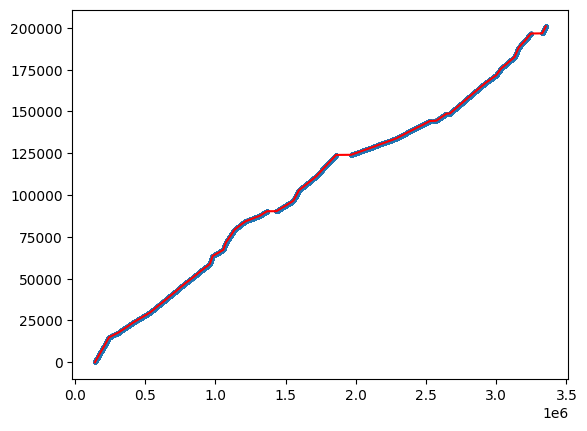

In [6]:
import matplotlib.pyplot as plt

patientunitstayid = sorted(patient.patientunitstayid.tolist())
plt.scatter(patientunitstayid,[x for x in range(1,len(patientunitstayid)+1)],s=3)
plt.plot(patientunitstayid,[x for x in range(1,len(patientunitstayid)+1)],c='red')
plt.show()

In [7]:
def gen_cdf(keys):
    cdf = []
    total = len(keys)
    for i in range(total):
        if i <= total -2:
            if keys[i] != keys[i+1]:
                cdf.append(i/total)
            else:
                continue
        else:
            cdf.append(1.0)
    return cdf




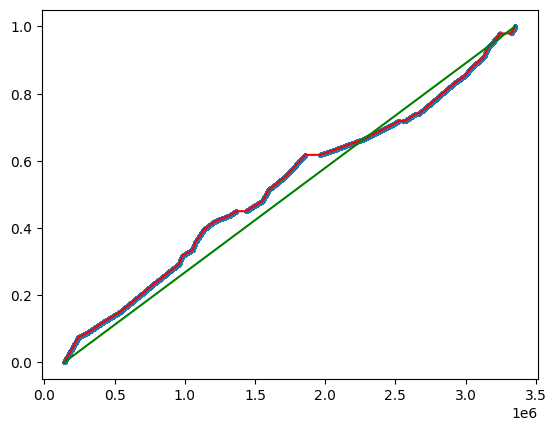

In [8]:
patientunitstayid_cdf = gen_cdf(patientunitstayid)
patientunitstayid_uniform = [x for x in range(patientunitstayid[0],patientunitstayid[-1]+1)]
patientunitstayid_uniform_cdf = gen_cdf(patientunitstayid_uniform)
plt.scatter(patientunitstayid,patientunitstayid_cdf,s=3)
plt.plot(patientunitstayid,patientunitstayid_cdf,c='red')
# plt.scatter(patientunitstayid_uniform,patientunitstayid_uniform_cdf,s=3)
plt.plot(patientunitstayid_uniform,patientunitstayid_uniform_cdf,c='green')
plt.show()

In [9]:
print(200859*patientunitstayid_cdf[256])

256.0


In [10]:
# from scipy.stats import entropy
# import numpy as np
# # 假设P和Q是两个概率分布
# P = np.array(patientunitstayid_cdf)
# Q = np.array(patientunitstayid_uniform_cdf)
#
# KL = entropy(patientunitstayid_uniform_cdf,patientunitstayid_cdf)
# print(KL)

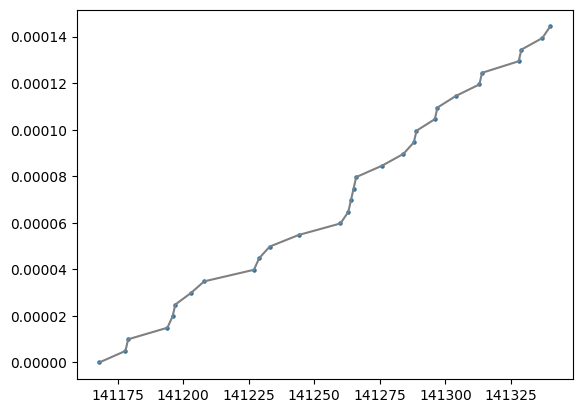

In [11]:
low = 0
upper = 30
plt.plot(patientunitstayid[low:upper],patientunitstayid_cdf[low:upper],c='gray')
plt.scatter(patientunitstayid[low:upper],patientunitstayid_cdf[low:upper],s=5)

# 2 分布转换

In [12]:
import numpy as np
def load(model, optimizer, path):
  checkpoint = torch.load(path)
  model.load_state_dict(checkpoint["model"])
  optimizer.load_state_dict(checkpoint["optimizer"])

def save(model, optimizer, path):
  d = {}
  d["model"] = model.state_dict()
  d["optimizer"] = optimizer.state_dict()
  torch.save(d, path)

def save_weights(model, mean, var, args, weight_path):
  f = open(weight_path, 'w')
  model.eval()
  f.write('%d\t%d\t%d\n' % (args['input_dim'], args['input_dim'] * args['hidden_dim'], args['num_layers']))
  f.write('%.16f\t%.16f\n' % (mean.item(), var.item()))
  model.save_weights(f)
  f.close()

def train(train_keys, model, optimizer, scheduler, best_loss, args, model_path):
  model.train()
  model = model.to(args['device'])
  last_loss = None
  batch_size = args['batch_dim']
  for epoch in range(args['steps']):
    print('Epoch:{}'.format(epoch))
    start_time = time.time()
    epoch_loss = 0
    num_batches = int(np.ceil(train_keys.shape[0] / batch_size))
    iterator = trange(num_batches, smoothing=0, dynamic_ncols=True)
    for i in iterator:
      l = i * batch_size
      r = np.min([(i + 1) * batch_size, train_keys.shape[0]])
      x = train_keys[l:r].to(args['device'])
      loss = model.loss(x)
      if np.isnan(loss.item()):
        print('Error: Loss is NaN')
        exit()
      if np.isinf(loss.item()):
        print('Error: Loss is INF')
        exit()

      epoch_loss += loss.item()
      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=args['clip_norm'])
      optimizer.step()
      optimizer.zero_grad()
      scheduler.step(loss)

      iterator.set_postfix(
        loss="{:.2f}".format(loss.data.cpu().numpy()), refresh=False
      )

    epoch_time = time.time() - start_time
    print('Time Cost of Epoch {}'.format(epoch_time))

    print('Epoch mean loss:{}'.format(epoch_loss / train_keys.shape[0]))
    if last_loss != None and (epoch_loss > last_loss
        or np.fabs((last_loss - epoch_loss) / last_loss) < 0.01):
      print('Process: Early stop at epoch-{}'.format(epoch))
      break
    if epoch_loss < best_loss:
      best_loss = epoch_loss
      save(model, optimizer, model_path)
    last_loss = epoch_loss

  return best_loss

def test(source_keys, model, args):
  model = model.to(args['device'])
  model.eval()
  tran_keys = None
  with torch.no_grad():
    batch_size = 8192
    num_batches = int(np.ceil(source_keys.shape[0] / batch_size))
    iterator = trange(num_batches, smoothing=0, dynamic_ncols=True)
    for i in iterator:
      l = i * batch_size
      r = np.min([(i + 1) * batch_size, source_keys.shape[0]])
      x = source_keys[l:r].to(args['device'])
      z = model(x).to('cpu')
      if torch.isnan(z).any():
        print('Error: Nan keys')
        exit()
      tran_keys = torch.cat((tran_keys, z), 0) if tran_keys != None else z
  return tran_keys

Process: Loading data...
Time Cost of Loading data 0.007998228073120117
Process: Evaluating original keys [torch.Size([200859, 1])]...
Process: Using Min-Max Normalization
Min 0.0 Max 1000000.0
Encoder configs	{'shifts': 1000000, 'keep_res': True}
Decoder configs	{}
Process: Spliting training data...
Number of training keys 20085
Process: Spliting training data...
Number of training keys 20085
Process: Spliting training data...
Number of training keys 20085
Parameters=10, n_dims=2
Partition(feature_dim=2, shifts=1000000, keep_res=True)
BNAFSequential(
  (0): BNAF(res=False)(
    (0): MaskedWeight(in_features=2, out_features=2, dim=2, bias=False)
    (1): BNAFTanh()
    (2): MaskedWeight(in_features=2, out_features=2, dim=2, bias=False)
  )
)
SumDecoder()

Process: 1 Training...
Epoch:0


100%|██████████| 5/5 [00:00<00:00, 11.00it/s, loss=666696.98] 


Time Cost of Epoch 0.4587876796722412
Epoch mean loss:228.6260168570835
Epoch:1


100%|██████████| 5/5 [00:00<00:00, 137.73it/s, loss=328432.28]


Time Cost of Epoch 0.03888821601867676
Epoch mean loss:110.74112005648492
Epoch:2


...

100%|██████████| 25/25 [00:00<00:00, 852.56it/s]


Process: Sorting keys...
Process: Evaluating the transformed keys...
####################################################################################################
Assess the 200859 of keys
Number of unordered keys 0
Number of duplicated keys 0
Range [0.0, 2.687368722622527]
Slope 537831.8341813062, intercept 0.5
Space amplification 7.195853807895091
Absolute Conflicts
Total conflicts 16365, max conflict 3, 99% conflict 2, average conflict 1.0643210197710717
Slope 537831.8341813062, intercept 0.5
Space amplification 1.499992532074739
Limited Space Conflicts
Total conflicts 181657, max conflict 180870, 99% conflict 2, average conflict 237.46013071895425
Slope 74741.88350454098, intercept 0.5
Space amplification 1.0
Proportional Building
Total conflicts 83814, max conflict 8, 99% conflict 4, average conflict 1.5575915257387103
####################################################################################################
Process: Sample data for plotting...


100%|██████████| 13/13 [00:00<00:00, 875.20it/s]

Process: Plot the transofmred distribution...



E:\学习资料\2023秋\数学建模\2023正式比赛\pythonProject\eicu\numerical_flow.py:30: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, hist=False, kde=False, fit=stats.norm,


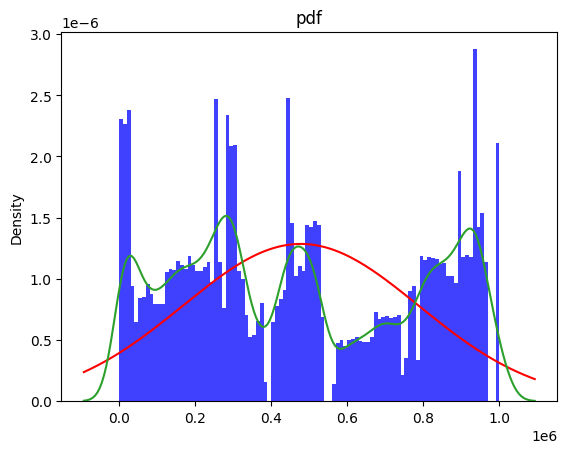

保存图像成功


E:\学习资料\2023秋\数学建模\2023正式比赛\pythonProject\eicu\numerical_flow.py:30: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, hist=False, kde=False, fit=stats.norm,


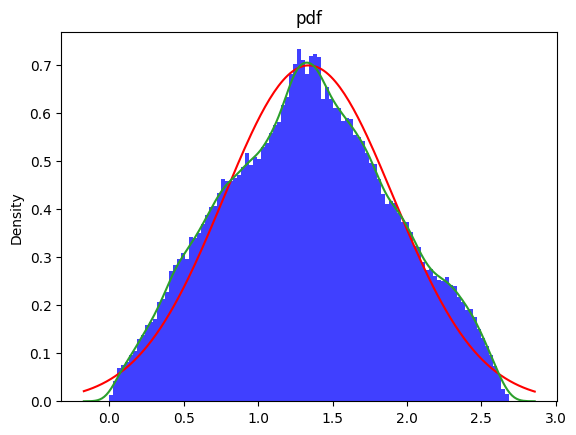

保存图像成功


E:\学习资料\2023秋\数学建模\2023正式比赛\pythonProject\eicu\numerical_flow.py:30: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, hist=False, kde=False, fit=stats.norm,


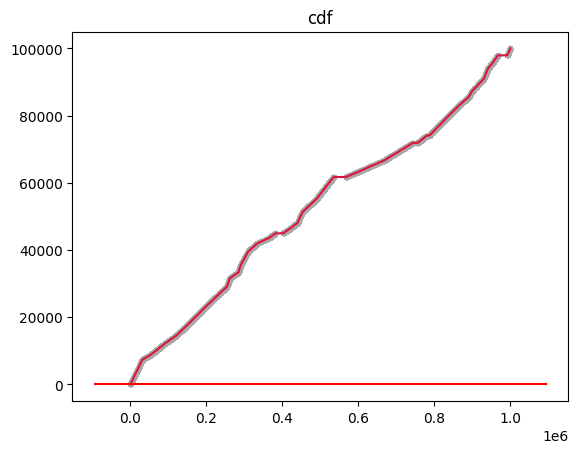

保存图像成功


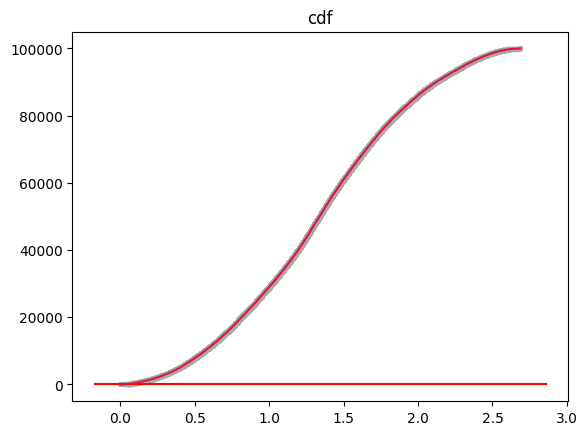

保存图像成功


In [13]:
import datetime
from eicu.assess_quality import evaluate_keys
from eicu.Diatrbution_Transformation import DistTransformer
import torch
import os
import random

args ={'device':'cuda:0','data_dir':'data','data_name':'patientunitstayid',
       'seed':1000000013,'plot':True,'log_file':True,
       'encoder_type':'partition','decoder_type':'sum','shifts':1000000,
       'keep_res':True,'reduce_dim':-1,'num_flows':1,
       'num_layers':2,'input_dim':2,'hidden_dim':1,
       'train_ratio':0.1,'num_train':3,'learning_rate':1e-1,
       'clip_norm':.1,'steps':15,'patience':2000,
       'decay':0.5,'batch_dim':4096,'loss_func':'normal',
       'load':None,}

if not os.path.exists('checkpoint'):
    os.mkdir('checkpoint')

now = datetime.datetime.now()
time_str = '-%4d-%02d-%02d-%02d-%02d-%02d' % (now.year, now.month, now.day, now.hour, now.minute, now.second)
checkpoint_dir = os.path.join('checkpoint', args['data_name'] + time_str)
if not os.path.exists(checkpoint_dir):
    os.mkdir(checkpoint_dir)
model_path = os.path.join(checkpoint_dir, 'checkpoint.pt')

# Set random seed
random_seed = args['seed']
seed = random_seed
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

if args['log_file']:
    log_filename = os.path.join(checkpoint_dir, 'outputs.log')
    log_f = open(log_filename, 'w')
else:
    log_f = None

# print('Process: Saving arguments...')
# with open(os.path.join(checkpoint_dir, 'argsjson'), 'w') as f:
#     json.dump(args__dict__, f, indent=4, sort_keys=True)
#
# print('Arguments')
# pprint.pprint(args__dict__)

# Loading data, analyzing data, segmenting data
print('Process: Loading data...')
start_time = time.time()


######### 加载数据 #########
load_keys = torch.Tensor(patientunitstayid).reshape(-1,1)
load_durations = time.time() - start_time
print('Time Cost of Loading data {}'.format(load_durations))

print('Process: Evaluating original keys [{}]...'.format(load_keys.size()))
# evaluate_keys(load_keys.detach().cpu().numpy().squeeze(), log_f=log_f)

print('Process: Using Min-Max Normalization')
# 维度扩张的前序步骤，对应伪代码1-4行
global_mean = torch.min(load_keys)
global_var = (torch.max(load_keys) - torch.min(load_keys)) / args['shifts']
load_keys = (load_keys - global_mean) / global_var
print('Min {} Max {}'.format(torch.min(load_keys), torch.max(load_keys)))
if args['log_file']:
    print('Min {} Max {}'.format(torch.min(load_keys), torch.max(load_keys)), file=log_f)

encoder_config = {}
decoder_config = {}
if args['encoder_type'] == 'partition':
    encoder_config['shifts'] = args['shifts']
    encoder_config['keep_res'] = args['keep_res']

if args['decoder_type'] == 'reduce':
    decoder_config['reduce_dim'] = args['reduce_dim']
elif args['decoder_type'] == 'shift_sum':
    decoder_config['shifts'] = args['shifts']
    decoder_config['keep_res'] = args['keep_res']
print('Encoder configs\t{}'.format(encoder_config))
print('Decoder configs\t{}'.format(decoder_config))
if args['log_file']:
    print('Encoder configs\t{}'.format(encoder_config), file=log_f)
    print('Decoder configs\t{}'.format(decoder_config), file=log_f)

#训练集数据
num_train_keys = np.max((np.clip(int(load_keys.shape[0] * args['train_ratio']),
                          1, load_keys.shape[0]), 10000))
train_keys_list = []
for i in range(args['num_train']):
    print('Process: Spliting training data...')
    print('Number of training keys {}'.format(num_train_keys))
    if args['log_file']:
      print('Number of training keys {}'.format(num_train_keys), file=log_f)
    train_keys = sample_data(load_keys, num_train_keys)
    train_keys_list.append(train_keys)

model = DistTransformer(args['num_flows'], args['num_layers'], args['input_dim'],
                          args['hidden_dim'], args['encoder_type'], encoder_config,
                          args['decoder_type'], decoder_config)
optimizer = torch.optim.Adam(model.parameters(), lr=args['learning_rate'],
                                amsgrad=True,foreach=False)#!!!!
print('Parameters={}, n_dims={}'.format(sum((p != 0).sum()
        if len(p.shape) > 1 else torch.tensor(p.shape).item()
        for p in model.parameters()), args['input_dim']))
print('{}'.format(model))

if args['log_file']:
    print('Parameters={}, n_dims={}'.format(sum((p != 0).sum()
          if len(p.shape) > 1 else torch.tensor(p.shape).item()
          for p in model.parameters()), args['input_dim']), file=log_f)
    oldstdout = sys.stdout
    sys.stdout = log_f
    print('{}'.format(model))
    sys.stdout = oldstdout

if args['load'] != None:
    load_path = os.path.join(args['load'], 'checkpoint.pt')
    checkpoint = torch.load(load_path)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
else:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                  factor=args['decay'], patience=args['patience'], min_lr=5e-4,
                  verbose=True, threshold_mode='abs')
    best_loss = 1e20
    for i, train_keys in enumerate(train_keys_list):
      print('Process: {} Training...'.format(i + 1))
      start_time = time.time()
      best_loss = train(train_keys, model, optimizer, scheduler, best_loss, args, model_path)
      train_durations = time.time() - start_time
      print('Time Cost of Training {}'.format(train_durations))
      if args['log_file']:
        print('Time Cost of Training {}'.format(train_durations), file=log_f)
      load(model, optimizer, model_path)

print('Process: Saving weights for c++ inference...')
weight_path = os.path.join(checkpoint_dir, args['data_name'] + '-weights.txt')
save_weights(model, global_mean, global_var, args, weight_path)

print('Process: Transforming keys...')
tran_keys = test(load_keys, model, args)

num_unordered = ((tran_keys[1:] - tran_keys[:-1]) < 0).sum().item()
if num_unordered > 0:
    print('Process: Sorting keys...')
    tran_keys = torch.sort(tran_keys, 0)[0]

print('Process: Evaluating the transformed keys...')
evaluate_keys(tran_keys.detach().cpu().numpy().squeeze(), log_f=log_f)

if args['plot']:
    num_samples = 100000
    if load_keys.shape[0] > num_samples:
        print('Process: Sample data for plotting...')
        plot_keys = sample_data(load_keys, num_samples)
        plot_keys = torch.sort(plot_keys, 0)[0]
        tran_keys = test(plot_keys, model, args)
    print('Process: Plot the transofmred distribution...')
    plot_dist(plot_keys.detach().cpu().numpy().squeeze(), os.path.join(checkpoint_dir, args['data_name'] + '_load_dist'), 'pdf')
    plot_dist(tran_keys.detach().cpu().numpy().squeeze(), os.path.join(checkpoint_dir, args['data_name'] + '_tran_dist'), 'pdf')
    plot_dist(plot_keys.detach().cpu().numpy().squeeze(), os.path.join(checkpoint_dir, args['data_name'] + '_load_dist'), 'cdf')
    plot_dist(tran_keys.detach().cpu().numpy().squeeze(), os.path.join(checkpoint_dir, args['data_name'] + '_tran_dist'), 'cdf')

In [14]:
transed_keys = test(load_keys, model, args)
transed_keys = np.sort(transed_keys.detach().cpu().numpy(), axis=0)


100%|██████████| 25/25 [00:00<00:00, 484.85it/s]


In [29]:
print(transed_keys)

[[0.00000000e+00]
 [1.83047065e-03]
 [3.52745934e-03]
 ...
 [2.68405104e+00]
 [2.68562337e+00]
 [2.68736872e+00]]


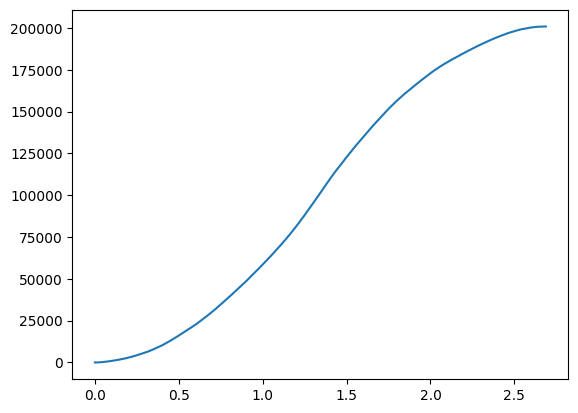

In [16]:
plt.plot(transed_keys,[x for x in range(len(transed_keys))])

In [17]:
print(load_keys[1:2])

tensor([[3.1132329523]])


In [18]:
t = test(load_keys[1:2], model, args)

100%|██████████| 1/1 [00:00<00:00, 189.31it/s]


In [81]:
print(load_keys[1:2])
print(((patientunitstayid[1] -global_mean)/global_var).reshape(1,-1))

tensor([[3.1132329523]])
tensor([[3.1132329523]])


In [20]:
t[0].item()*load_keys.shape[0]

31974.291630132775

# 2 CDF切分

In [23]:
def slope(x1, x2, y1, y2):
    """两点斜率"""
    return (y2 - y1) / (x2 - x1)

def mutation(keys):
    slopes = []
    delta_slope = [np.array([0.0])]
    for i in range(len(keys)-1):
        slopes.append(slope(keys[i], keys[i + 1],i,i+1))
    slopes.append(np.array([0.0]))

    for j in range(1,len(slopes)):
        delta_slope.append(abs(slopes[j]-slopes[j-1]))
    return delta_slope


In [50]:
mutations = np.array(mutation(transed_keys))

In [51]:
mutations

array([[   0.        ],
       [  42.97153637],
       [ 121.84601763],
       ...,
       [2321.03067754],
       [  63.04604369],
       [ 572.95086903]])

In [52]:
mutation_point1 = transed_keys[np.argmax(mutations)]
print(mutation_point1)

[0.57824129]


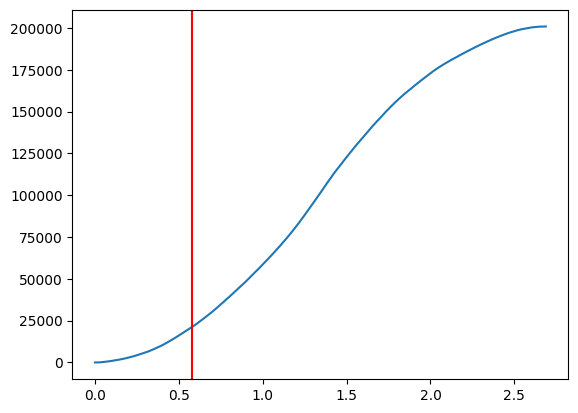

In [53]:
plt.plot(transed_keys,[x for x in range(len(transed_keys))])
plt.axvline(x=mutation_point1, color='r')
plt.show()

[0.57824129]
[1.38620874]


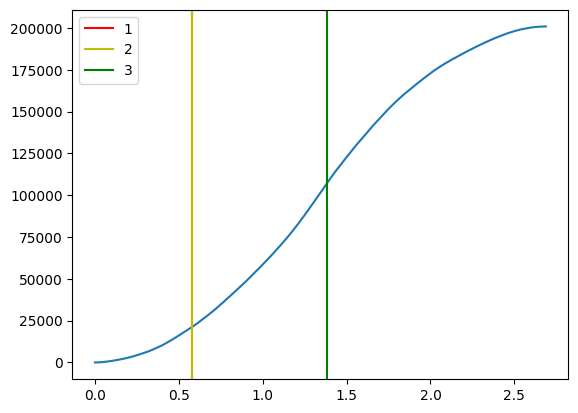

In [54]:
mutations[np.argmax(mutations)]=0

mutation_point2 = transed_keys[np.argmax(mutations)]
print(mutation_point2)

mutations[np.argmax(mutations)]=0

mutation_point3 = transed_keys[np.argmax(mutations)]
print(mutation_point3)
plt.plot(transed_keys,[x for x in range(len(transed_keys))])
plt.axvline(x=mutation_point1, color='r',label='1')
plt.axvline(x=mutation_point2, color='y',label='2')
plt.axvline(x=mutation_point3, color='g',label='3')
plt.legend()
plt.show()

In [55]:
from sklearn.linear_model import LinearRegression


#todo: 写递归划分算法
def linear(linear_x, linear_y):
    """线性模型"""
    linear_model = LinearRegression()
    linear_model.fit(linear_x, linear_y)
    return linear_model

results = []
mutation_points = []
mutation_point_indexs = []
def cut_and_fit(keys,pos,mutations,low,up):
    if low + 1 == up:
        results.append([low,up,np.array([1.0]),np.array([1.0])])
        return
    # if low + 1 == up:
    #     results.append([low,up,np.array([1/(keys[up]-keys[low])]),keys[low],np.array([1.0])])
    #     return
    model = linear(keys[low:up],pos[low:up])
    R2 = model.score(keys[low:up],pos[low:up])
    if  R2>=0.981481:
        results.append([low,up,model.coef_,model.intercept_,R2])
        return
    else:
        mutation_point_index = (np.argmax(mutations[low:up]).item()+low)
        # print(type(mutation_point_index))
        mutation_point = keys[mutation_point_index]
        mutation_points.append(mutation_point)
        mutation_point_indexs.append(mutation_point_index)

        mutations[mutation_point_index] = np.array([0.0])
        if low < mutation_point_index:
            cut_and_fit(keys,pos,mutations,low,mutation_point_index)
        if mutation_point_index < up:
            cut_and_fit(keys,pos,mutations,mutation_point_index,up)



In [56]:
pos = np.arange(0,len(transed_keys)).reshape(-1,1)
cut_and_fit(transed_keys,pos,mutations,0,len(transed_keys)-1)

In [102]:
print(pos)

[[     0]
 [     1]
 [     2]
 ...
 [200856]
 [200857]
 [200858]]


In [57]:
print(len(results))
print(results)

14
[[0, 1990, array([[14342.64321098]]), array([-417.6900466]), 0.9847419187798753], [1990, 9674, array([[34027.00941374]]), array([-4008.37253214]), 0.989584652905241], [9674, 9675, array([1.]), array([1.])], [9675, 22797, array([[62248.34861154]]), array([-14886.32471645]), 0.9990038359084874], [22797, 53343, array([[88743.48556838]]), array([-31520.97992228]), 0.9985539615810617], [53343, 75837, array([[108443.12048083]]), array([-49857.41046504]), 0.9994106032435377], [75837, 107597, array([[138934.83968293]]), array([-85336.46300788]), 0.9995387970785601], [107597, 107598, array([1.]), array([1.])], [107598, 114638, array([[140351.15625713]]), array([-86957.99102249]), 0.9998723424997759], [114638, 114639, array([1.]), array([1.])], [114639, 121043, array([[127901.3398302]]), array([-69148.19493263]), 0.9998982662820228], [121043, 148292, array([[117116.62322302]]), array([-52667.89621569]), 0.9994607930719053], [148292, 178016, array([[83557.99201404]]), array([5833.61570809]), 0

In [58]:
# print(mutation_points)
mutation_points_copy = mutation_points
mutation_points.append(transed_keys[0])
mutation_points.append(transed_keys[-1])
mutation_points=np.sort(mutation_points,axis=0)



In [59]:
print(mutation_points)
print(len(mutation_points))

[[0.        ]
 [0.159612  ]
 [0.38824098]
 [0.38824098]
 [0.60177413]
 [0.94824189]
 [1.1558821 ]
 [1.38620874]
 [1.38620874]
 [1.43698135]
 [1.43698135]
 [1.48658262]
 [1.71943342]
 [2.07530382]
 [2.68736872]]
15


## 2.1 绘制分割结果图

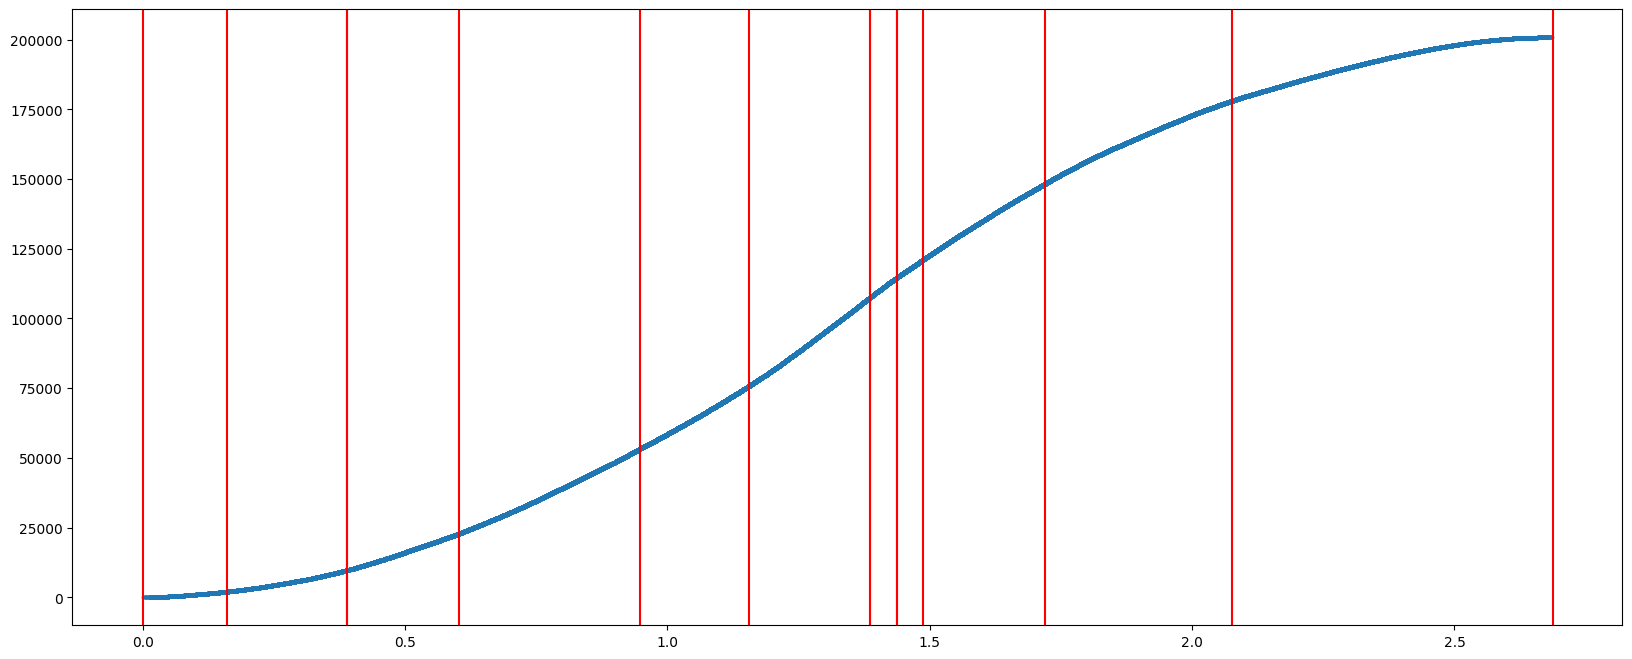

In [60]:
def gen_pre(keys,coef,intercept):
    return keys*coef + intercept
fig = plt.figure(figsize=(20,8))
l = 0
u = -1
plt.scatter(transed_keys[l:u],pos[l:u],s=3)
# plt.plot(transed_keys,gen_pre(transed_keys,results[0][2],results[0][3]))
for point in mutation_points:
    plt.axvline(x=point, color='r')
plt.show()

# 3 查询算法

In [89]:
def find_model(arr, x:torch.Tensor):
    arr.reshape(-1,)
    x = x.item()
    left, right = 0, len(arr) - 1
    result_index = -1  # 初始值设为-1，表示不存在小于等于 x 的数

    while left <= right:
        mid = (left + right) // 2

        if arr[mid] <= x:
            result_index = mid  # 更新结果的索引
            left = mid + 1      # 向右搜索
        else:
            right = mid - 1     # 向左搜索

    if result_index > 0:
        if arr[result_index-1] == x:
            result_index -= 1

    return result_index

print(find_model(np.array([[1], [3], [4], [6], [8], [10], [10], [14], [14]]),torch.Tensor([[10]])))



5


In [90]:
sorted(results,key=lambda x: x[0])

[[0,
  1990,
  array([[14342.64321098]]),
  array([-417.6900466]),
  0.9847419187798753],
 [1990,
  9674,
  array([[34027.00941374]]),
  array([-4008.37253214]),
  0.989584652905241],
 [9674, 9675, array([1.]), array([1.])],
 [9675,
  22797,
  array([[62248.34861154]]),
  array([-14886.32471645]),
  0.9990038359084874],
 [22797,
  53343,
  array([[88743.48556838]]),
  array([-31520.97992228]),
  0.9985539615810617],
 [53343,
  75837,
  array([[108443.12048083]]),
  array([-49857.41046504]),
  0.9994106032435377],
 [75837,
  107597,
  array([[138934.83968293]]),
  array([-85336.46300788]),
  0.9995387970785601],
 [107597, 107598, array([1.]), array([1.])],
 [107598,
  114638,
  array([[140351.15625713]]),
  array([-86957.99102249]),
  0.9998723424997759],
 [114638, 114639, array([1.]), array([1.])],
 [114639,
  121043,
  array([[127901.3398302]]),
  array([-69148.19493263]),
  0.9998982662820228],
 [121043,
  148292,
  array([[117116.62322302]]),
  array([-52667.89621569]),
  0.99946079

In [108]:
def query(key,model,args,results,mutation_points):
    normal_key = ((key -global_mean)/global_var).reshape(1,-1)
    tk = test(normal_key,model,args)
    print(tk.item())
    m = results[find_model(mutation_points,tk)]
    print(m)
    p = tk*m[2] + m[3]
    print(p)



In [110]:
query(patientunitstayid[1000],model,args,results,mutation_points)

100%|██████████| 1/1 [00:00<00:00, 198.80it/s]

1.1930517441881119
[75837, 107597, array([[138934.83968293]]), array([-85336.46300788]), 0.9995387970785601]
tensor([[80419.9898043321]])


In [107]:
print(patientunitstayid[1])

141178
